CATBOOST(Only 2): 250: test: 0.9646784
<br>
CATBOOST(Only 3): 500: test: 0.9984941
<br>
<br>
Random Forest(Only 2): 250: test: 0.9777446010693702, 500: test: 0.9777677476101196
<br>
Random Forest(Only 3): 250: test: 0.9981176116256306, 500: test: 0.9981929071606054
<br>
<br>
XGBoost(Only 2): 500: test: 0.9783232645881073, 750: test: 0.9782075318843599
<br>
XGBoost(Only 3): 250: test: 0.9984187937655297

## CatBoost

loading dataset...
dataset loaded!


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.8122590	test: 0.8119595	best: 0.8119595 (0)	total: 482ms	remaining: 4m
1:	learn: 0.8582818	test: 0.8577780	best: 0.8577780 (1)	total: 937ms	remaining: 3m 53s
2:	learn: 0.8644731	test: 0.8639976	best: 0.8639976 (2)	total: 1.23s	remaining: 3m 23s
3:	learn: 0.8772443	test: 0.8764063	best: 0.8764063 (3)	total: 1.48s	remaining: 3m 3s
4:	learn: 0.8821104	test: 0.8809287	best: 0.8809287 (4)	total: 1.76s	remaining: 2m 53s
5:	learn: 0.8827027	test: 0.8815588	best: 0.8815588 (5)	total: 2.02s	remaining: 2m 46s
6:	learn: 0.8882385	test: 0.8873667	best: 0.8873667 (6)	total: 2.3s	remaining: 2m 41s
7:	learn: 0.8893252	test: 0.8881493	best: 0.8881493 (7)	total: 2.66s	remaining: 2m 43s
8:	learn: 0.8908245	test: 0.8900294	best: 0.8900294 (8)	total: 2.97s	remaining: 2m 41s
9:	learn: 0.8900329	test: 0.8889623	best: 0.8900294 (8)	total: 3.2s	remaining: 2m 37s
10:	learn: 0.8907178	test: 0.8897651	best: 0.8900294 (8)	total: 3.46s	remaining: 2m 33s
11:	learn: 0.8921954	test: 0.8911879	best: 0.8911

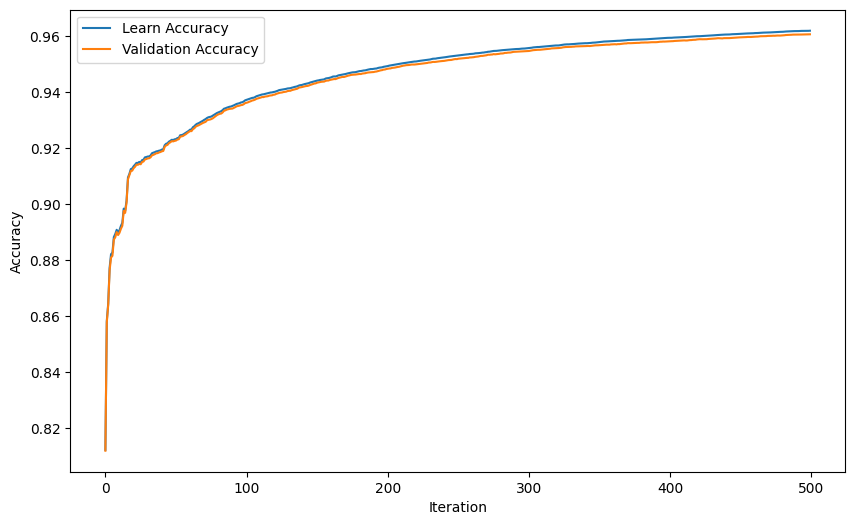

Best Train Accuracy: 0.9619062863066247
Best Validation Accuracy: 0.9606296811959472
Score Validation Accuracy: 0.9606296811959472
Score Test Accuracy: 0.9604469534906174


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

print("loading dataset...")

labeled_dataset = pd.read_csv('data/labeled_processed_4Categories.csv')

print("dataset loaded!")

train, temp = train_test_split(
    labeled_dataset,
    test_size=0.3,
    random_state=1,
    stratify=labeled_dataset['event_type']
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=1,
    stratify=temp['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

val_features = val.drop(fields_to_drop, axis=1)
val_labels = val['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']

classifier = CatBoostClassifier(
    iterations=500,
    max_depth=7,
    random_seed=2,
    learning_rate=0.1,
    eval_metric="Accuracy",
    loss_function="MultiClass"
)

classifier.fit(
    train_features, train_labels,
    eval_set=(val_features, val_labels),
    verbose=1,
    plot=True
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
print(f"Best Validation Accuracy: {classifier.evals_result_['validation']['Accuracy'][-1]}")

validation_score = classifier.score(val_features, val_labels)
print(f"Score Validation Accuracy: {validation_score}")

test_score = classifier.score(test_features, test_labels)
print(f"Score Test Accuracy: {test_score}")

## Random Forest

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

print("loading dataset...")

labeled_dataset = pd.read_csv('data/labeled_processed_4Categories.csv')

print("dataset loaded!")

train, temp = train_test_split(
    labeled_dataset,
    test_size=0.3,
    random_state=1,
    stratify=labeled_dataset['event_type']
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=1,
    stratify=temp['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

val_features = val.drop(fields_to_drop, axis=1)
val_labels = val['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']


classifier = RandomForestClassifier(
    n_estimators=150,       # Dropped from 250 to save memory/time; 150 is usually plenty
    max_depth=None,         # Allow trees to grow deep to capture complex patterns
    min_samples_leaf=20,    # Prevents tiny, overfitted branches on 1M rows
    max_features="sqrt",    # Looks at a subset of columns per split (speeds up training)
    random_state=2,
    n_jobs=-1,              # Uses all CPU cores (critical for 1M rows)
    verbose=1
)

classifier.fit(train_features, train_labels)

train_score = classifier.score(train_features, train_labels)
print(f"Train Accuracy: {train_score}")

val_score = classifier.score(val_features, val_labels)
print(f"Validation Accuracy: {val_score}")

test_score = classifier.score(test_features, test_labels)
print(f"Test Accuracy: {test_score}")


loading dataset...
dataset loaded!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   43.5s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  2.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    5.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Train Accuracy: 0.9720108929401683


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    1.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Validation Accuracy: 0.9677080051626541


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s


Test Accuracy: 0.9675557294498448


[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    1.1s finished


## XGBoost

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("loading dataset...")

labeled_dataset = pd.read_csv('data/labeled_processed_4Categories.csv')

print("dataset loaded!")

train, temp = train_test_split(
    labeled_dataset,
    test_size=0.3,
    random_state=1,
    stratify=labeled_dataset['event_type']
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=1,
    stratify=temp['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

val_features = val.drop(fields_to_drop, axis=1)
val_labels = val['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']

# Create a label encoder
label_encoder = LabelEncoder()
# Fit on all unique labels and transform
train_labels = label_encoder.fit_transform(train['event_type'])
val_labels = label_encoder.transform(val['event_type'])
test_labels = label_encoder.transform(test['event_type'])

classifier = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    random_state=2,
    learning_rate=0.1,
    eval_metric='mlogloss',
    verbosity=1,
    subsample=0.8, # Train each tree on 80% of rows (adds randomness, fights noise)
    colsample_bytree=0.8, # Use 80% of features per tree (prevents one feature from dominating)
    tree_method='hist',
    n_jobs=-1,
    num_early_stopping_rounds=25
)

classifier.fit(
    train_features, 
    train_labels,
    eval_set=[(val_features, val_labels)],
    verbose=True
)

train_score = classifier.score(train_features, train_labels)
print(f"Train Accuracy: {train_score}")

val_score = classifier.score(val_features, val_labels)
print(f"Validation Accuracy: {val_score}")

test_score = classifier.score(test_features, test_labels)
print(f"Test Accuracy: {test_score}")

loading dataset...
dataset loaded!


C:\Users\Actually whatever\Desktop\Uni\Master\Semester 3\Deep Learning\DeepLearningOscGrid\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [20:55:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:1.00134
[1]	validation_0-mlogloss:0.91122
[2]	validation_0-mlogloss:0.82695
[3]	validation_0-mlogloss:0.75707
[4]	validation_0-mlogloss:0.69637
[5]	validation_0-mlogloss:0.64487
[6]	validation_0-mlogloss:0.59965
[7]	validation_0-mlogloss:0.56021
[8]	validation_0-mlogloss:0.52628
[9]	validation_0-mlogloss:0.49435
[10]	validation_0-mlogloss:0.46565
[11]	validation_0-mlogloss:0.44319
[12]	validation_0-mlogloss:0.42136
[13]	validation_0-mlogloss:0.40117
[14]	validation_0-mlogloss:0.38301
[15]	validation_0-mlogloss:0.36657
[16]	validation_0-mlogloss:0.35272
[17]	validation_0-mlogloss:0.34045
[18]	validation_0-mlogloss:0.32888
[19]	validation_0-mlogloss:0.31764
[20]	validation_0-mlogloss:0.30835
[21]	validation_0-mlogloss:0.29827
[22]	validation_0-mlogloss:0.28932
[23]	validation_0-mlogloss:0.28006
[24]	validation_0-mlogloss:0.27095
[25]	validation_0-mlogloss:0.26336
[26]	validation_0-mlogloss:0.25520
[27]	validation_0-mlogloss:0.24815
[28]	validation_0-mlogloss:0.2